In [ ]:
from collections.abc import Sequence

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision import models

In [2]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Define transforms for data preprocessing
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [ ]:
# Load dataset (replace 'your_dataset_path' with actual path)
dataset = datasets.ImageFolder(
    root="/net/projects2/promega/lding/spectral_based_classes", transform=transform
)

# Split dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [5]:
# Load pretrained model (ResNet50 as example)
model = models.resnet50(pretrained=True)

# Modify the classifier head for new dataset
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(dataset.classes))  # Adjust to the number of classes
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

/home/ldin/anaconda3/envs/finetune-cnn/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ldin/anaconda3/envs/finetune-cnn/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Plot training and validation losses and accuracies
def plot_metrics(
    train_losses: Sequence[float],
    val_losses: Sequence[float],
    train_accuracies: Sequence[float],
    val_accuracies: Sequence[float],
) -> None:
    """Plots the training and validation loss and accuracy curves.

    Parameters:
    - train_losses (list or array-like): Loss values from the training set over epochs.
    - val_losses (list or array-like): Loss values from the validation set over epochs.
    - train_accuracies (list or array-like): Accuracy values from the training set over epochs.
    - val_accuracies (list or array-like): Accuracy values from the validation set over epochs.

    Returns:
    - None: This function displays the plots but does not return any value.
    """
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Training Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Training and Validation Accuracy")
    plt.legend()

    plt.show()

In [ ]:
# Training loop with loss and accuracy tracking
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    epochs: int = 30,
) -> None:
    """Trains a PyTorch model and tracks training/validation loss and accuracy over epochs.

    Parameters:
    - model (nn.Module): The PyTorch model to train.
    - train_loader (DataLoader): DataLoader for the training dataset.
    - val_loader (DataLoader): DataLoader for the validation dataset.
    - criterion (nn.Module): Loss function (e.g., nn.CrossEntropyLoss).
    - optimizer (torch.optim.Optimizer): Optimizer for updating model weights.
    - epochs (int, optional): Number of training epochs. Default is 30.

    Returns:
    - None: The function trains the model, plots metrics, and saves the best model to 'best_model.pth'.
    """
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    best_val_loss = float("inf")
    best_model_path = "best_model.pth"

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(100.0 * correct / total)

        val_loss, val_acc = evaluate_model(model, val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs}, Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.2f}%, Val Acc: {val_acc:.2f}%"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved with validation loss: {best_val_loss:.4f}")

    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)
    print(f"Training completed. Best model saved as {best_model_path}")

In [ ]:
# Evaluation function
def evaluate_model(model: nn.Module, val_loader: DataLoader) -> tuple[float, float]:
    """Evaluates the model on the validation set.

    Parameters:
    - model (nn.Module): The PyTorch model to evaluate.
    - val_loader (DataLoader): DataLoader for the validation dataset.

    Returns:
    - Tuple[float, float]: A tuple containing:
        - Average validation loss (float)
        - Validation accuracy as a percentage (float)
    """
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(val_loader), 100.0 * correct / total

Epoch 1/50, Loss: 0.5879, Train Acc: 67.33%, Val Acc: 71.05%
Best model saved with validation loss: 1.0547
Epoch 2/50, Loss: 0.2452, Train Acc: 88.67%, Val Acc: 73.68%
Epoch 3/50, Loss: 0.2475, Train Acc: 90.67%, Val Acc: 76.32%
Epoch 4/50, Loss: 0.0990, Train Acc: 96.00%, Val Acc: 36.84%
Epoch 5/50, Loss: 0.0444, Train Acc: 98.00%, Val Acc: 52.63%
Epoch 6/50, Loss: 0.0229, Train Acc: 99.33%, Val Acc: 63.16%
Epoch 7/50, Loss: 0.0262, Train Acc: 98.67%, Val Acc: 60.53%
Epoch 8/50, Loss: 0.0108, Train Acc: 100.00%, Val Acc: 78.95%
Epoch 9/50, Loss: 0.0140, Train Acc: 99.33%, Val Acc: 86.84%
Best model saved with validation loss: 0.8184
Epoch 10/50, Loss: 0.0025, Train Acc: 100.00%, Val Acc: 86.84%
Best model saved with validation loss: 0.7705
Epoch 11/50, Loss: 0.0927, Train Acc: 99.33%, Val Acc: 81.58%
Best model saved with validation loss: 0.7435
Epoch 12/50, Loss: 0.0091, Train Acc: 100.00%, Val Acc: 78.95%
Epoch 13/50, Loss: 0.0500, Train Acc: 97.33%, Val Acc: 89.47%
Epoch 14/50, Los

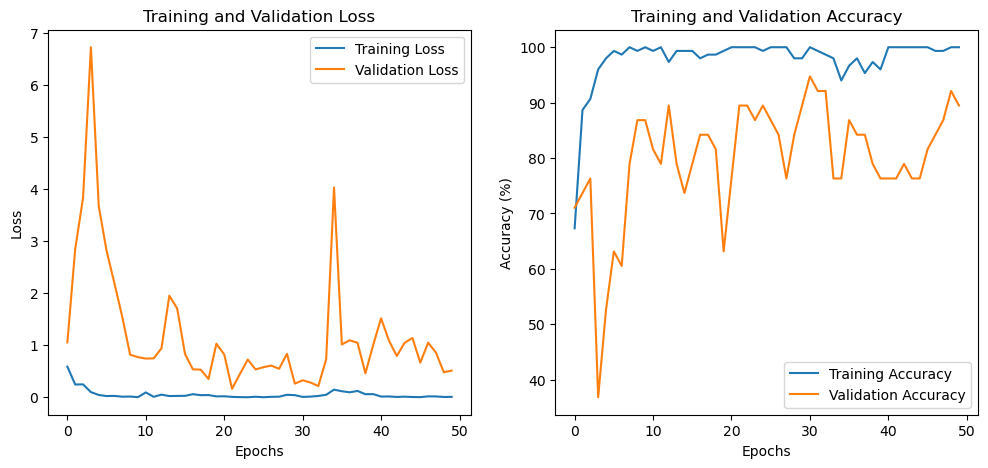

Training completed. Best model saved as best_model.pth
Model saved successfully!


In [9]:
# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50)

# Save the fine-tuned model
torch.save(model.state_dict(), "finetuned_model.pth")
print("Model saved successfully!")